In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\Diego\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{DBLP

In [3]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [4]:
nombres_clases = metadatos.features['label'].names
nombres_clases

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [5]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

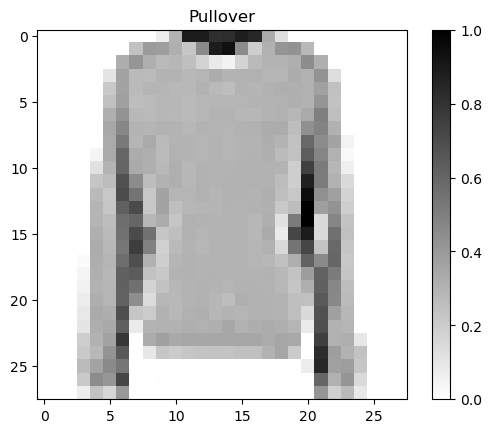

In [6]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break
imagen = imagen.numpy().reshape((28, 28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.title(nombres_clases[etiqueta])
plt.show()

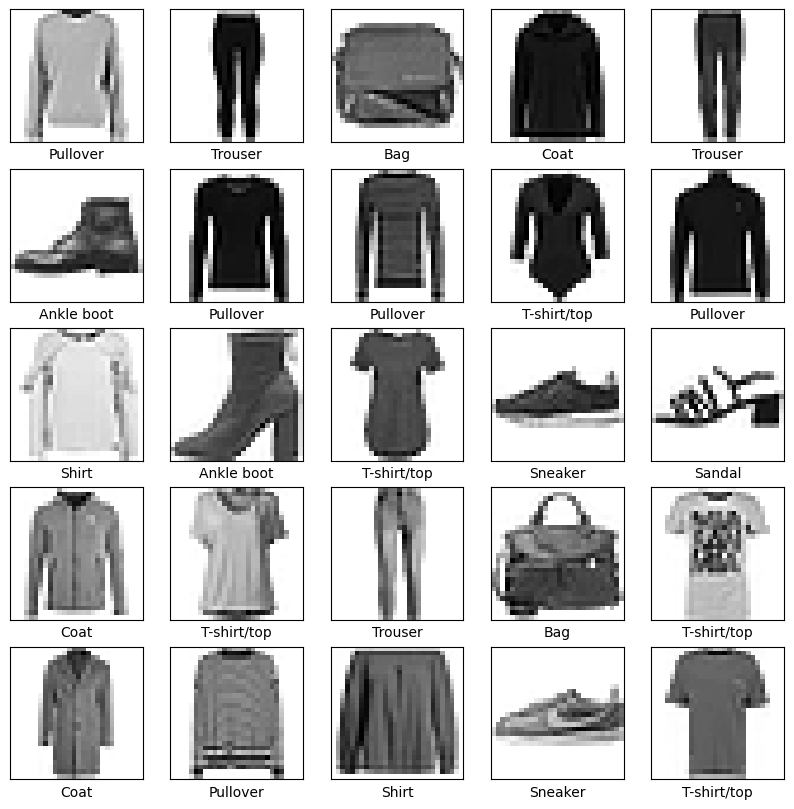

In [7]:
plt.figure(figsize=(10, 10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28, 28))
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])
plt.show()

In [8]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),       # Entrada: 784 neuronas
    tf.keras.layers.Dense(50, activation=tf.nn.relu),       # Capa oculta 1
    tf.keras.layers.Dense(50, activation=tf.nn.relu),       # Capa oculta 2
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)     # Capa de salida (clasificación)
])

modelo.summary()

c:\Users\Diego\anaconda3\envs\notebook\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,310 (165.27 KB)

 Trainable params: 42,310 (165.27 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [10]:
TAMANO_LOTE = 32

num_ej_entrenamiento = metadatos.splits["train"].num_examples
num_ej_pruebas = metadatos.splits["test"].num_examples
print("Entrenamiento:", num_ej_entrenamiento)
print("Pruebas:", num_ej_pruebas)

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

Entrenamiento: 60000
Pruebas: 10000


In [11]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=5,
    steps_per_epoch=math.ceil(num_ej_entrenamiento / TAMANO_LOTE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.7553 - loss: 0.6934
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8586 - loss: 0.3914
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8720 - loss: 0.3562
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8794 - loss: 0.3240
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8864 - loss: 0.3146


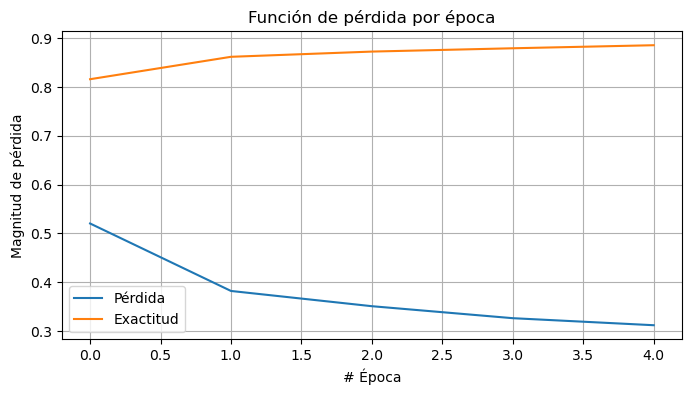

In [12]:
plt.figure(figsize=(8, 4))
plt.xlabel("# Época")
plt.ylabel("Magnitud de pérdida")
plt.title("Función de pérdida por época")
plt.plot(historial.history["loss"], label="Pérdida")
plt.plot(historial.history["accuracy"], label="Exactitud")
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


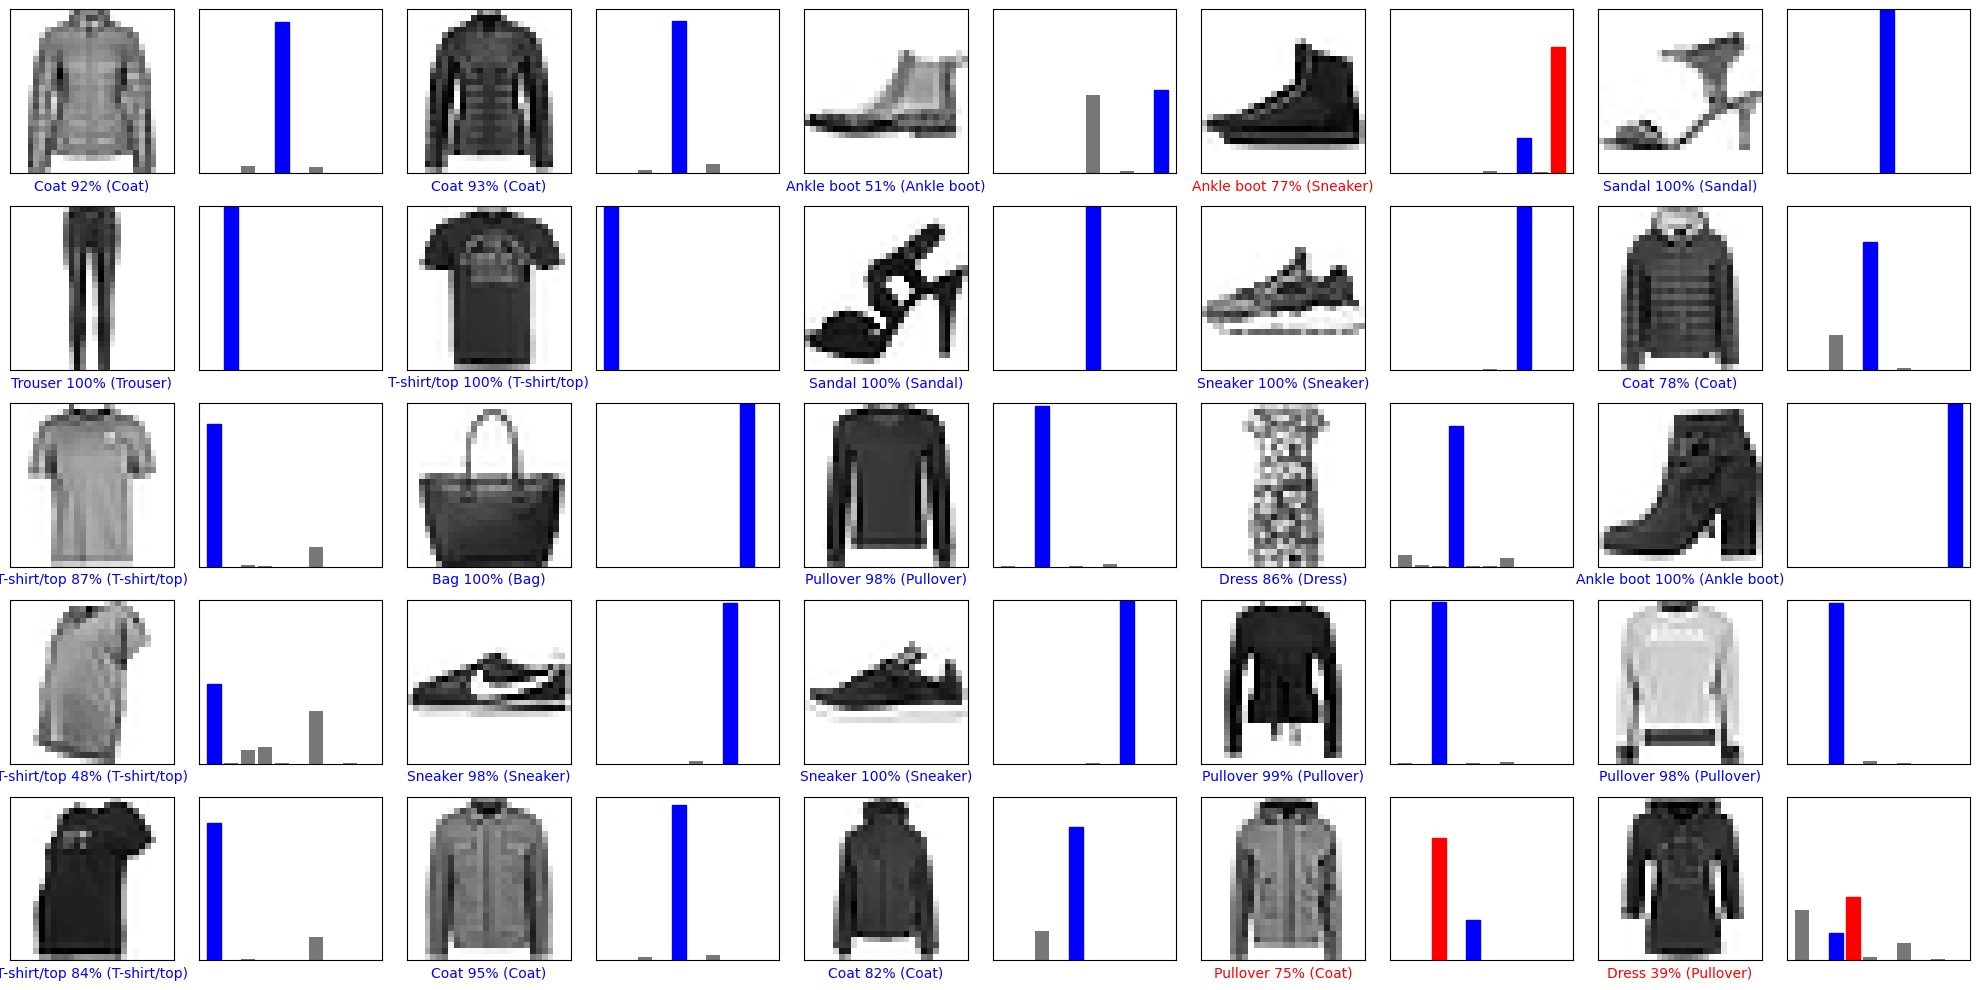

In [13]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[..., 0], cmap=plt.cm.binary)
    etiqueta_prediccion = np.argmax(arr_predicciones)
    color = 'blue' if etiqueta_prediccion == etiqueta_real else 'red'
    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100 * np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)
    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas * columnas
plt.figure(figsize=(2*2*columnas, 2*filas))
for i in range(num_imagenes):
    plt.subplot(filas, 2*columnas, 2*i+1)
    graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
    plt.subplot(filas, 2*columnas, 2*i+2)
    graficar_valor_arreglo(i, predicciones, etiquetas_prueba)
plt.tight_layout()
plt.show()

In [14]:
imagen = imagenes_prueba[24]
imagen = np.array([imagen])
prediccion = modelo.predict(imagen)

print("Predicción:", nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Predicción: Dress


In [15]:
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

# Widget para subir imagen
boton_subir = widgets.FileUpload(accept='image/*', multiple=False, description='Subir imagen')
salida = widgets.Output()

def clasificar_imagen(change):
    with salida:
        clear_output(wait=True)
        if boton_subir.value:
            archivo = boton_subir.value[0]
            contenido = archivo['content']
            
            img = Image.open(io.BytesIO(contenido))
            img = img.convert('L')
            img = img.resize((28, 28))
            img_array = np.array(img) / 255.0
            img_array = img_array.reshape(1, 28, 28, 1)
            
            pred = modelo.predict(img_array)
            clase_predicha = nombres_clases[np.argmax(pred[0])]
            confianza = 100 * np.max(pred[0])
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
            
            ax1.imshow(img_array.reshape(28, 28), cmap=plt.cm.binary)
            ax1.set_title("Imagen cargada")
            ax1.axis('off')
            
            colores = ['#cccccc'] * 10
            colores[np.argmax(pred[0])] = '#e74c3c'
            ax2.bar(nombres_clases, pred[0], color=colores)
            ax2.set_title(f"Predicción: {clase_predicha} ({confianza:.1f}%)")
            ax2.set_xticklabels(nombres_clases, rotation=45, ha='right')
            ax2.set_ylim([0, 1])
            
            plt.tight_layout()
            plt.show()
            print(f"\nCategoría predicha: {clase_predicha}")
            print(f"Confianza: {confianza:.2f}%")

boton_subir.observe(clasificar_imagen, names='value')

print("Sube una imagen de ropa para clasificarla:")
display(boton_subir, salida)

Sube una imagen de ropa para clasificarla:


FileUpload(value=(), accept='image/*', description='Subir imagen')

Output()

In [16]:
modelo.save('modelo_tienda_ropa.h5')
print("Modelo guardado como 'modelo_tienda_ropa.h5'")

Modelo guardado como 'modelo_tienda_ropa.h5'


# Actividades

1. as_supervised: Retorna el dataset como tuplas (imagen, etiqueta) en lugar de un diccionario, facilitando su uso en entrenamiento supervisado.

2. with_info: Retorna un objeto adicional con los metadatos del dataset, como nombres de clases, cantidad de ejemplos y descripción general.

3. map(): Aplica una función a cada elemento del dataset de forma automática y eficiente, en este caso para normalizar los píxeles de 0–255 a 0–1.

4. ¿Qué es el formato H5?
Es un formato de archivo que permite guardar un modelo de Machine Learning completo (arquitectura, pesos y configuración) para reutilizarlo después sin necesidad de volver a entrenarlo.